Setup

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set(style="whitegrid")


Load the data

In [75]:
# Load CSV
df = pd.read_csv("../data/benin-malanville.csv")

# Preview
df.head()
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525600 entries, 0 to 525599
Data columns (total 19 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Timestamp      525600 non-null  object 
 1   GHI            525600 non-null  float64
 2   DNI            525600 non-null  float64
 3   DHI            525600 non-null  float64
 4   ModA           525600 non-null  float64
 5   ModB           525600 non-null  float64
 6   Tamb           525600 non-null  float64
 7   RH             525600 non-null  float64
 8   WS             525600 non-null  float64
 9   WSgust         525600 non-null  float64
 10  WSstdev        525600 non-null  float64
 11  WD             525600 non-null  float64
 12  WDstdev        525600 non-null  float64
 13  BP             525600 non-null  int64  
 14  Cleaning       525600 non-null  int64  
 15  Precipitation  525600 non-null  float64
 16  TModA          525600 non-null  float64
 17  TModB          525600 non-nul

,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
count,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,0.0
mean,475.492396,348.965279,222.224081,236.589496,228.883576,28.179683,54.487969,2.121113,2.809195,0.473390,153.435172,8.582407,994.197199,0.000923,0.001905,35.246026,32.471736,NaN
std,228.385103,193.441746,107.493717,326.894859,316.536515,5.924297,28.073069,1.603466,2.029120,0.273395,102.332842,6.385864,2.474993,0.030363,0.037115,14.807258,12.348743,NaN
min,0.000000,0.000000,0.000000,0.000000,0.000000,11.000000,2.100000,0.000000,0.000000,0.000000,0.000000,0.000000,985.000000,0.000000,0.000000,9.000000,8.100000,NaN
25%,464.700000,345.700000,210.700000,0.000000,0.000000,24.200000,28.800000,1.000000,1.300000,0.400000,59.000000,3.700000,993.000000,0.000000,0.000000,24.200000,23.600000,NaN
50%,474.200000,345.700000,213.400000,4.500000,4.300000,28.000000,55.100000,1.900000,2.600000,0.500000,181.000000,8.600000,994.000000,0.000000,0.000000,30.000000,28.900000,NaN
75%,483.400000,345.700000,216.300000,463.700000,447.900000,32.300000,80.100000,3.100000,4.100000,0.600000,235.100000,12.300000,996.000000,0.000000,0.000000,46.900000,41.500000,NaN
max,1413.000000,952.300000,759.200000,1342.300000,1342.300000,43.800000,100.000000,19.500000,26.600000,4.200000,360.000000,99.400000,1003.000000,1.000000,2.500000,81.000000,72.500000,NaN


In [76]:
df.isna().sum()


Timestamp             0
GHI                   0
DNI                   0
DHI                   0
ModA                  0
ModB                  0
Tamb                  0
RH                    0
WS                    0
WSgust                0
WSstdev               0
WD                    0
WDstdev               0
BP                    0
Cleaning              0
Precipitation         0
TModA                 0
TModB                 0
Comments         525600
dtype: int64

Basic Info & Missing Values

In [77]:
df.isna().sum()


Timestamp             0
GHI                   0
DNI                   0
DHI                   0
ModA                  0
ModB                  0
Tamb                  0
RH                    0
WS                    0
WSgust                0
WSstdev               0
WD                    0
WDstdev               0
BP                    0
Cleaning              0
Precipitation         0
TModA                 0
TModB                 0
Comments         525600
dtype: int64

Convert Timestamp

In [78]:
# Let pandas automatically detect the standard format
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Now sort the values
df = df.sort_values('Timestamp')


Handle Negative Values & Missing Data

In [79]:
for col in ['GHI','DNI','DHI','ModA','ModB']:
    df[col] = df[col].apply(lambda x: np.nan if x < 0 else x)


numeric_cols = ['GHI','DNI','DHI','ModA','ModB','Tamb','RH','WS','WSgust','WSstdev','BP','Precipitation','TModA','TModB']
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())


In [80]:
df[numeric_cols]

,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,BP,Precipitation,TModA,TModB
0,474.2,345.7,213.4,0.0,0.0,26.2,93.4,0.0,0.4,0.1,998,0.0,26.3,26.2
1,474.2,345.7,213.4,0.0,0.0,26.2,93.6,0.0,0.0,0.0,998,0.0,26.3,26.2
2,474.2,345.7,213.4,0.0,0.0,26.2,93.7,0.3,1.1,0.5,997,0.0,26.4,26.2
3,474.2,345.7,213.4,0.0,0.0,26.2,93.3,0.2,0.7,0.4,997,0.0,26.4,26.3
4,474.2,345.7,213.4,0.0,0.0,26.2,93.3,0.1,0.7,0.3,997,0.0,26.4,26.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
525595,474.2,345.7,213.4,0.0,0.0,23.1,98.3,0.3,1.1,0.5,996,0.0,23.5,22.9
525596,474.2,345.7,213.4,0.0,0.0,23.1,98.3,0.2,0.7,0.4,996,0.0,23.5,22.9
525597,474.2,345.7,213.4,0.0,0.0,23.1,98.4,0.6,1.1,0.5,996,0.0,23.5,22.9
525598,474.2,345.7,213.4,0.0,0.0,23.1,98.3,0.9,1.3,0.5,996,0.0,23.5,22.9


Detect Outliers (Z-score)

In [81]:
z_scores = np.abs(stats.zscore(df[numeric_cols]))
outliers = (z_scores > 3).sum(axis=0)
print("Outliers detected per column:\n", outliers)


Outliers detected per column:
 [ 416   85 8628   27   63    0    0 3109 3500 5653  865 1402   10   98]


Correlation & Heatmap

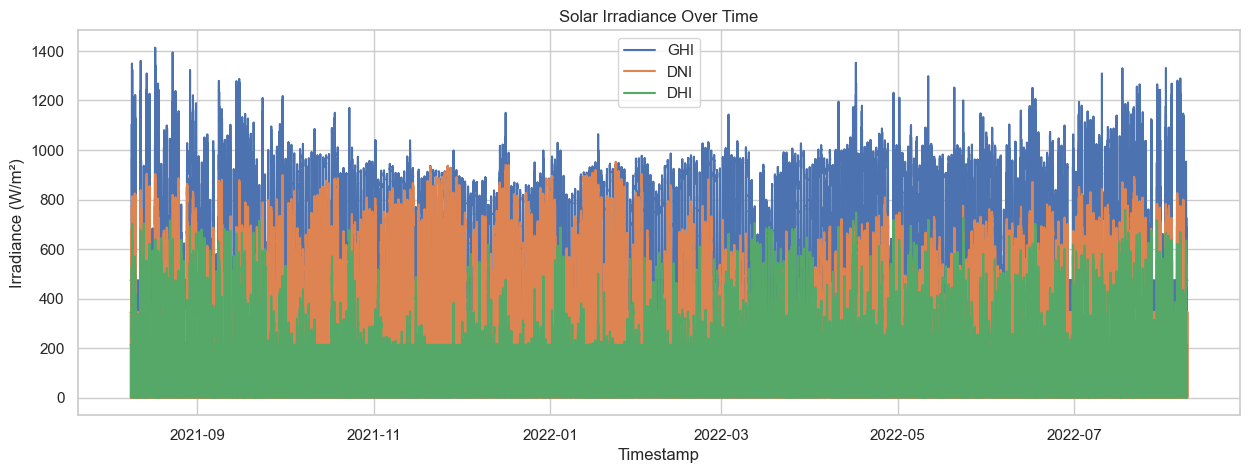

In [82]:
plt.figure(figsize=(15,5))
plt.plot(df['Timestamp'], df['GHI'], label='GHI')
plt.plot(df['Timestamp'], df['DNI'], label='DNI')
plt.plot(df['Timestamp'], df['DHI'], label='DHI')
plt.xlabel("Timestamp")
plt.ylabel("Irradiance (W/m²)")
plt.title("Solar Irradiance Over Time")
plt.legend()
plt.show()


Scatter Plots

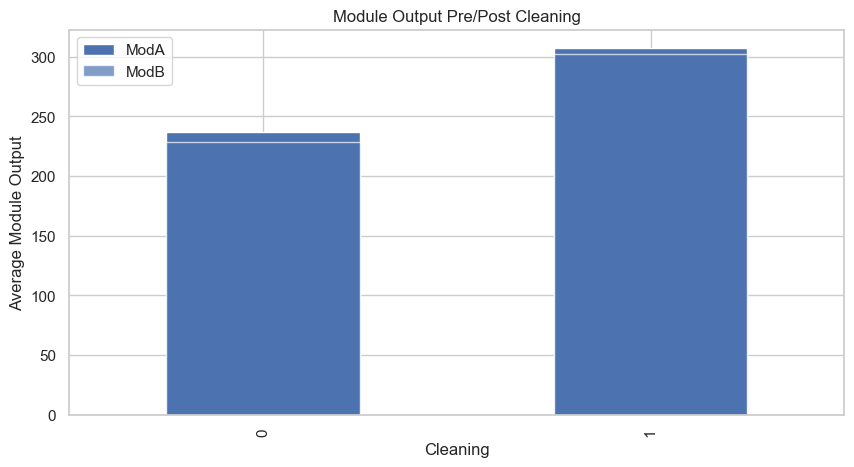

In [83]:
plt.figure(figsize=(10,5))
df.groupby('Cleaning')['ModA'].mean().plot(kind='bar', label='ModA')
df.groupby('Cleaning')['ModB'].mean().plot(kind='bar', label='ModB', alpha=0.7)
plt.title("Module Output Pre/Post Cleaning")
plt.ylabel("Average Module Output")
plt.legend()
plt.show()


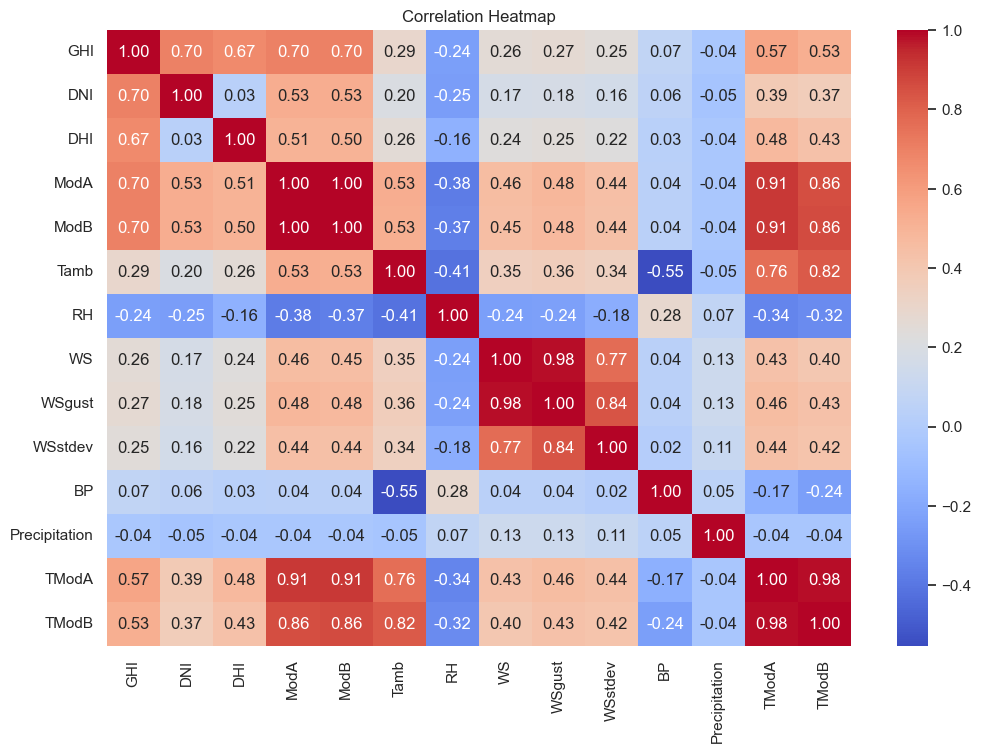

In [84]:
plt.figure(figsize=(12,8))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


Distribution Plots

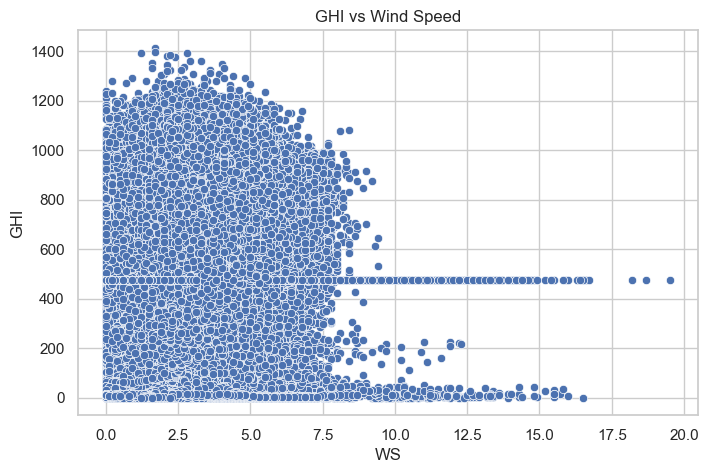

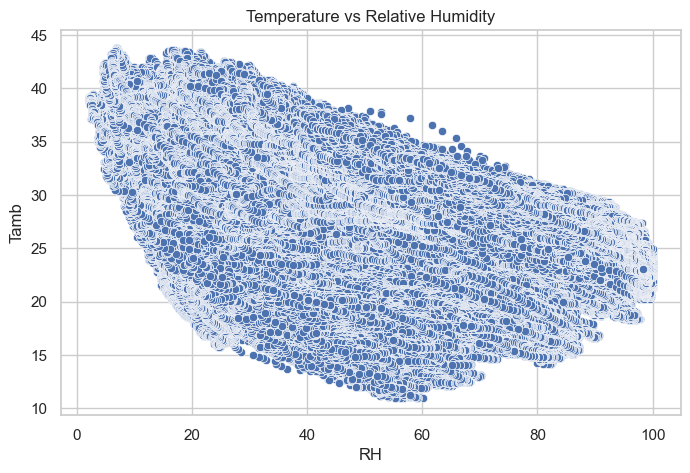

In [85]:
# GHI vs WS
plt.figure(figsize=(8,5))
sns.scatterplot(x='WS', y='GHI', data=df)
plt.title("GHI vs Wind Speed")
plt.show()

# RH vs Tamb
plt.figure(figsize=(8,5))
sns.scatterplot(x='RH', y='Tamb', data=df)
plt.title("Temperature vs Relative Humidity")
plt.show()


Bubble Plot

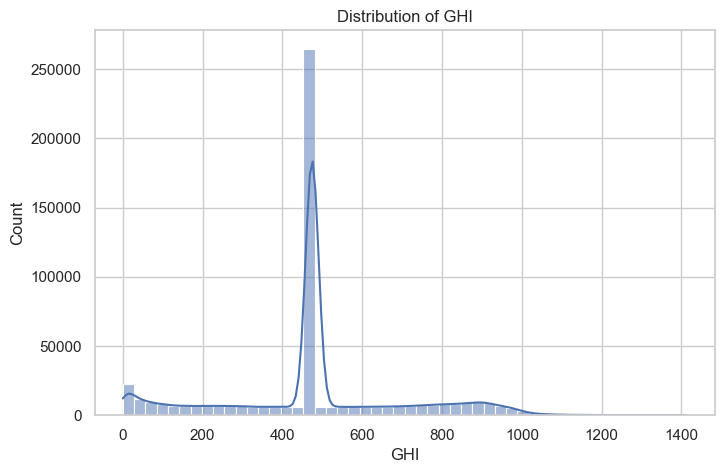

In [86]:
plt.figure(figsize=(8,5))
sns.histplot(df['GHI'], bins=50, kde=True)
plt.title("Distribution of GHI")
plt.show()


Export Cleaned Data

In [87]:
df.to_csv("../data/benin-malanville.csv", index=False)
